# CNN vs Improved CRNN — UrbanSound8K
**Dataset:** UrbanSound8K · **Input:** Mel Spectrogram (128×128) · **Evaluation:** 10-fold CV  
**Models:** CNN (baseline) vs Improved CRNN  

### CRNN improvements over the original:
1. **Asymmetric pooling** in ConvBlocks 3 & 4 — pools frequency axis only, preserving 32 time steps (vs 8 in original)
2. **Attention pooling** over all LSTM outputs — replaces last-step-only extraction
3. **Single LSTM layer** — reduces overfitting on the small dataset (~7.8k train clips per fold)

## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import soundata

print(f'PyTorch : {torch.__version__}')
print(f'Librosa : {librosa.__version__}')
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')

PyTorch : 2.11.0
Librosa : 0.11.0
Device  : mps


## 2. Configuration

In [2]:
dataset = soundata.initialize('urbansound8k')
dataset.download()
dataset.validate()
DATASET_PATH = dataset.data_home
METADATA_CSV = os.path.join(DATASET_PATH, 'metadata', 'UrbanSound8K.csv')
AUDIO_DIR    = os.path.join(DATASET_PATH, 'audio')

SAMPLE_RATE  = 22050
DURATION     = 4
N_MELS       = 128
N_FFT        = 2048
HOP_LENGTH   = 512
IMG_SIZE     = 128
NUM_CLASSES  = 10
BATCH_SIZE   = 32
EPOCHS       = 30
LR           = 1e-3
WEIGHT_DECAY = 1e-4

CLASS_NAMES = [
    'air_conditioner', 'car_horn', 'children_playing', 'dog_bark',
    'drilling', 'engine_idling', 'gun_shot', 'jackhammer',
    'siren', 'street_music'
]

os.makedirs('results_cnn_crnn', exist_ok=True)
os.makedirs('checkpoints_cnn',  exist_ok=True)
os.makedirs('checkpoints_crnn_improved', exist_ok=True)
print('Config ready.')

INFO: Downloading ['all', 'index']. Index is being stored in /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/soundata/datasets/indexes, and the rest of files in /Users/rujuta/sound_datasets/urbansound8k
INFO: [all] downloading UrbanSound8K.tar.gz
INFO: /Users/rujuta/sound_datasets/urbansound8k/UrbanSound8K.tar.gz already exists and will not be downloaded. Rerun with force_overwrite=True to delete this file and force the download.
INFO: /Users/rujuta/sound_datasets/urbansound8k/UrbanSound8K_README.txt already exists. Run with force_overwrite=True to download from scratch
INFO: /Users/rujuta/sound_datasets/urbansound8k/FREESOUNDCREDITS.txt already exists. Run with force_overwrite=True to download from scratch
INFO: /Users/rujuta/sound_datasets/urbansound8k/audio already exists. Run with force_overwrite=True to download from scratch
INFO: /Users/rujuta/sound_datasets/urbansound8k/metadata already exists. Run with force_overwrite=True to download from scratc

Config ready.


## 3. Feature Extraction

In [3]:
def load_mel_spectrogram(filepath):
    """Load .wav → normalised (N_MELS, IMG_SIZE) mel spectrogram."""
    try:
        y, sr = librosa.load(filepath, sr=SAMPLE_RATE, mono=True, duration=DURATION)
    except Exception as e:
        print(f'  Warning: {filepath} — {e}')
        return None

    target_len = SAMPLE_RATE * DURATION
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT,
                                             hop_length=HOP_LENGTH, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] != IMG_SIZE:
        mel_db = np.array([
            np.interp(
                np.linspace(0, mel_db.shape[1] - 1, IMG_SIZE),
                np.arange(mel_db.shape[1]), row
            ) for row in mel_db
        ])

    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    return mel_db.astype(np.float32)

## 4. Dataset

In [4]:
class UrbanSoundDataset(Dataset):
    def __init__(self, df, augment=False):
        self.samples = []
        self.labels  = []
        self.augment = augment

        for _, row in tqdm(df.iterrows(), total=len(df), desc='Loading'):
            path  = os.path.join(AUDIO_DIR, f'fold{row["fold"]}', row['slice_file_name'])
            mel   = load_mel_spectrogram(path)
            if mel is not None:
                self.samples.append(mel)
                self.labels.append(int(row['classID']))

        self.samples = np.array(self.samples)
        self.labels  = np.array(self.labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        mel   = self.samples[idx].copy()
        label = self.labels[idx]
        if self.augment:
            mel = self._spec_augment(mel)
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)  # (1, 128, 128)
        return mel, torch.tensor(label, dtype=torch.long)

    def _spec_augment(self, mel):
        t  = np.random.randint(0, IMG_SIZE // 4)
        t0 = np.random.randint(0, IMG_SIZE - t)
        mel[:, t0:t0 + t] = 0
        f  = np.random.randint(0, N_MELS // 8)
        f0 = np.random.randint(0, N_MELS - f)
        mel[f0:f0 + f, :] = 0
        return mel


metadata = pd.read_csv(METADATA_CSV)
print(f'Total clips : {len(metadata)}')

Total clips : 8732


## 5. CNN Architecture

In [5]:
class ConvBlock(nn.Module):
    """Conv → BN → ReLU → Conv → BN → ReLU → MaxPool → Dropout2D
    pool can be an int (symmetric) or (freq, time) tuple (asymmetric).
    """
    def __init__(self, in_ch, out_ch, kernel=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=kernel, padding=kernel // 2),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=kernel, padding=kernel // 2),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(pool),
            nn.Dropout2d(0.2),
        )

    def forward(self, x):
        return self.block(x)


class UrbanSoundCNN(nn.Module):
    """
    Input      : (B, 1, 128, 128)
    ConvBlock1 : 1  →  32  | 128×128 → 64×64
    ConvBlock2 : 32 →  64  |  64×64  → 32×32
    ConvBlock3 : 64 → 128  |  32×32  → 16×16
    ConvBlock4 : 128→ 256  |  16×16  →  8×8
    GAP        : → (B, 256)
    FC         : 256 → 128 → 10
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1,   32),
            ConvBlock(32,  64),
            ConvBlock(64,  128),
            ConvBlock(128, 256),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.gap(self.features(x)))


dummy = torch.zeros(2, 1, 128, 128)
cnn_test = UrbanSoundCNN()
print(f'CNN output shape    : {cnn_test(dummy).shape}')
print(f'CNN trainable params: {sum(p.numel() for p in cnn_test.parameters() if p.requires_grad):,}')

CNN output shape    : torch.Size([2, 10])
CNN trainable params: 1,207,786


## 6. Improved CRNN Architecture

```
Input      : (B, 1, 128, 128)
ConvBlock1 : pool=2     → (B,  32, 64, 64)   ← symmetric pool
ConvBlock2 : pool=2     → (B,  64, 32, 32)   ← symmetric pool
ConvBlock3 : pool=(2,1) → (B, 128, 16, 32)   ← freq-only pool ✓
ConvBlock4 : pool=(2,1) → (B, 256,  8, 32)   ← freq-only pool ✓
FreqPool   : AdaptiveAvgPool2d((1,32)) → (B, 256, 32)
Permute    : (B, 32, 256)
BiLSTM×1   : → (B, 32, 256)                  ← 32 time steps (was 8)
Attention  : softmax over time → (B, 256)     ← uses all steps (was last only)
FC head    : 256 → 128 → 10
```

In [6]:
class UrbanSoundCRNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, lstm_hidden=128, lstm_layers=1):
        super().__init__()

        # Blocks 1-2: symmetric pool (halve both axes)
        # Blocks 3-4: asymmetric pool (halve freq only → 32 time steps preserved)
        self.features = nn.Sequential(
            ConvBlock(1,   32,  pool=2),
            ConvBlock(32,  64,  pool=2),
            ConvBlock(64,  128, pool=(2, 1)),
            ConvBlock(128, 256, pool=(2, 1)),
        )
        # After blocks: (B, 256, 8, 32)
        # Collapse freq axis, keep 32 time steps
        self.freq_pool = nn.AdaptiveAvgPool2d((1, 32))
        # (B, 256, 1, 32) → squeeze → (B, 256, 32) → permute → (B, 32, 256)

        self.lstm = nn.LSTM(
            input_size    = 256,
            hidden_size   = lstm_hidden,
            num_layers    = lstm_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = 0.3 if lstm_layers > 1 else 0.0,
        )
        lstm_out_size = lstm_hidden * 2  # bidirectional

        # Attention: scalar score per time step
        self.attn = nn.Linear(lstm_out_size, 1)

        self.classifier = nn.Sequential(
            nn.Linear(lstm_out_size, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)          # (B, 256, 8, 32)
        x = self.freq_pool(x)         # (B, 256, 1, 32)
        x = x.squeeze(2)              # (B, 256, 32)
        x = x.permute(0, 2, 1)        # (B, 32, 256)  — time first
        out, _ = self.lstm(x)         # (B, 32, 256)
        # Attention pooling over all 32 time steps
        attn_w = torch.softmax(self.attn(out), dim=1)  # (B, 32, 1)
        x = (out * attn_w).sum(dim=1)                  # (B, 256)
        return self.classifier(x)


dummy = torch.zeros(2, 1, 128, 128)
crnn_test = UrbanSoundCRNN()
print(f'CRNN output shape    : {crnn_test(dummy).shape}')
print(f'CRNN trainable params: {sum(p.numel() for p in crnn_test.parameters() if p.requires_grad):,}')
print(crnn_test)

CRNN output shape    : torch.Size([2, 10])
CRNN trainable params: 1,603,307
UrbanSoundCRNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.2, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, ke

## 7. Training Helpers

In [7]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct    += (out.detach().argmax(1) == y).sum().item()
        total      += x.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out  = model(x)
        total_loss += criterion(out, y).item() * x.size(0)
        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total   += x.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


def run_fold(model, tr_ds, vl_ds, fold_num, ckpt_dir):
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    vl_loader = DataLoader(vl_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_acc, best_state = 0.0, None
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in tqdm(range(1, EPOCHS + 1), desc=f'  Fold {fold_num}', leave=False):
        tr_loss, tr_acc        = train_one_epoch(model, tr_loader, criterion, optimizer)
        vl_loss, vl_acc, _, _  = evaluate(model, vl_loader, criterion)
        scheduler.step()
        history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc);   history['val_acc'].append(vl_acc)
        if vl_acc > best_acc:
            best_acc   = vl_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    torch.save(best_state, f'{ckpt_dir}/fold{fold_num}.pt')
    _, acc, preds, labels = evaluate(model, vl_loader, criterion)
    return acc, f1_score(labels, preds, average='weighted'), preds, labels, history


print('Helpers defined.')

Helpers defined.


## 8. 10-Fold Cross-Validation — CNN

In [8]:
cnn_fold_accs, cnn_fold_f1s = [], []
cnn_all_labels, cnn_all_preds = [], []

for val_fold in range(1, 11):
    print(f'\n[CNN] Fold {val_fold}/10')
    tr_df = metadata[metadata['fold'] != val_fold].reset_index(drop=True)
    vl_df = metadata[metadata['fold'] == val_fold].reset_index(drop=True)

    tr_ds = UrbanSoundDataset(tr_df, augment=True)
    vl_ds = UrbanSoundDataset(vl_df, augment=False)

    acc, f1, preds, labels, _ = run_fold(
        UrbanSoundCNN(), tr_ds, vl_ds, val_fold, 'checkpoints_cnn'
    )
    cnn_fold_accs.append(acc)
    cnn_fold_f1s.append(f1)
    cnn_all_labels.extend(labels)
    cnn_all_preds.extend(preds)
    print(f'  Acc {acc:.4f}  F1 {f1:.4f}')

print(f'\nCNN  Mean Acc {np.mean(cnn_fold_accs):.4f} ± {np.std(cnn_fold_accs):.4f}')
print(f'CNN  Mean F1  {np.mean(cnn_fold_f1s):.4f} ± {np.std(cnn_fold_f1s):.4f}')


[CNN] Fold 1/10


Loading:   0%|          | 0/7859 [00:00<?, ?it/s]

Loading:   0%|          | 0/873 [00:00<?, ?it/s]

  Fold 1:   0%|          | 0/30 [00:00<?, ?it/s]

  Acc 0.7491  F1 0.7467

[CNN] Fold 2/10


...

  Acc 0.8395  F1 0.8334

[CNN] Fold 10/10


Loading:   0%|          | 0/7895 [00:00<?, ?it/s]

Loading:   0%|          | 0/837 [00:00<?, ?it/s]

  Fold 10:   0%|          | 0/30 [00:00<?, ?it/s]

  Acc 0.7921  F1 0.7902

CNN  Mean Acc 0.7716 ± 0.0474
CNN  Mean F1  0.7673 ± 0.0484


## 9. 10-Fold Cross-Validation — Improved CRNN

In [9]:
crnn_fold_accs, crnn_fold_f1s = [], []
crnn_all_labels, crnn_all_preds = [], []

for val_fold in range(1, 11):
    print(f'\n[CRNN] Fold {val_fold}/10')
    tr_df = metadata[metadata['fold'] != val_fold].reset_index(drop=True)
    vl_df = metadata[metadata['fold'] == val_fold].reset_index(drop=True)

    tr_ds = UrbanSoundDataset(tr_df, augment=True)
    vl_ds = UrbanSoundDataset(vl_df, augment=False)

    acc, f1, preds, labels, _ = run_fold(
        UrbanSoundCRNN(), tr_ds, vl_ds, val_fold, 'checkpoints_crnn_improved'
    )
    crnn_fold_accs.append(acc)
    crnn_fold_f1s.append(f1)
    crnn_all_labels.extend(labels)
    crnn_all_preds.extend(preds)
    print(f'  Acc {acc:.4f}  F1 {f1:.4f}')

print(f'\nCRNN Mean Acc {np.mean(crnn_fold_accs):.4f} ± {np.std(crnn_fold_accs):.4f}')
print(f'CRNN Mean F1  {np.mean(crnn_fold_f1s):.4f} ± {np.std(crnn_fold_f1s):.4f}')


[CRNN] Fold 1/10


Loading:   0%|          | 0/7859 [00:00<?, ?it/s]

Loading:   0%|          | 0/873 [00:00<?, ?it/s]

  Fold 1:   0%|          | 0/30 [00:00<?, ?it/s]

  Acc 0.7973  F1 0.7950

[CRNN] Fold 2/10


...

  Acc 0.7782  F1 0.7601

[CRNN] Fold 10/10


Loading:   0%|          | 0/7895 [00:00<?, ?it/s]

Loading:   0%|          | 0/837 [00:00<?, ?it/s]

  Fold 10:   0%|          | 0/30 [00:00<?, ?it/s]

  Acc 0.8112  F1 0.8099

CRNN Mean Acc 0.7522 ± 0.0386
CRNN Mean F1  0.7456 ± 0.0402


## 10. Summary Table

In [10]:
print(f'{"Model":<10}  {"Mean Acc":>10}  {"Std Acc":>8}  {"Mean F1":>10}  {"Std F1":>8}')
print('-' * 52)
for name, accs, f1s in [("CNN", cnn_fold_accs, cnn_fold_f1s),
                         ("CRNN", crnn_fold_accs, crnn_fold_f1s)]:
    print(f'{name:<10}  {np.mean(accs):>10.4f}  {np.std(accs):>8.4f}  '
          f'{np.mean(f1s):>10.4f}  {np.std(f1s):>8.4f}')
print('-' * 52)
delta_acc = np.mean(crnn_fold_accs) - np.mean(cnn_fold_accs)
delta_f1  = np.mean(crnn_fold_f1s)  - np.mean(cnn_fold_f1s)
print(f'{"Δ CRNN-CNN":<10}  {delta_acc:>+10.4f}  {"":>8}  {delta_f1:>+10.4f}')

Model         Mean Acc   Std Acc     Mean F1    Std F1
----------------------------------------------------
CNN             0.7716    0.0474      0.7673    0.0484
CRNN            0.7522    0.0386      0.7456    0.0402
----------------------------------------------------
Δ CRNN-CNN     -0.0194               -0.0217


## 11. Per-Fold Accuracy & F1

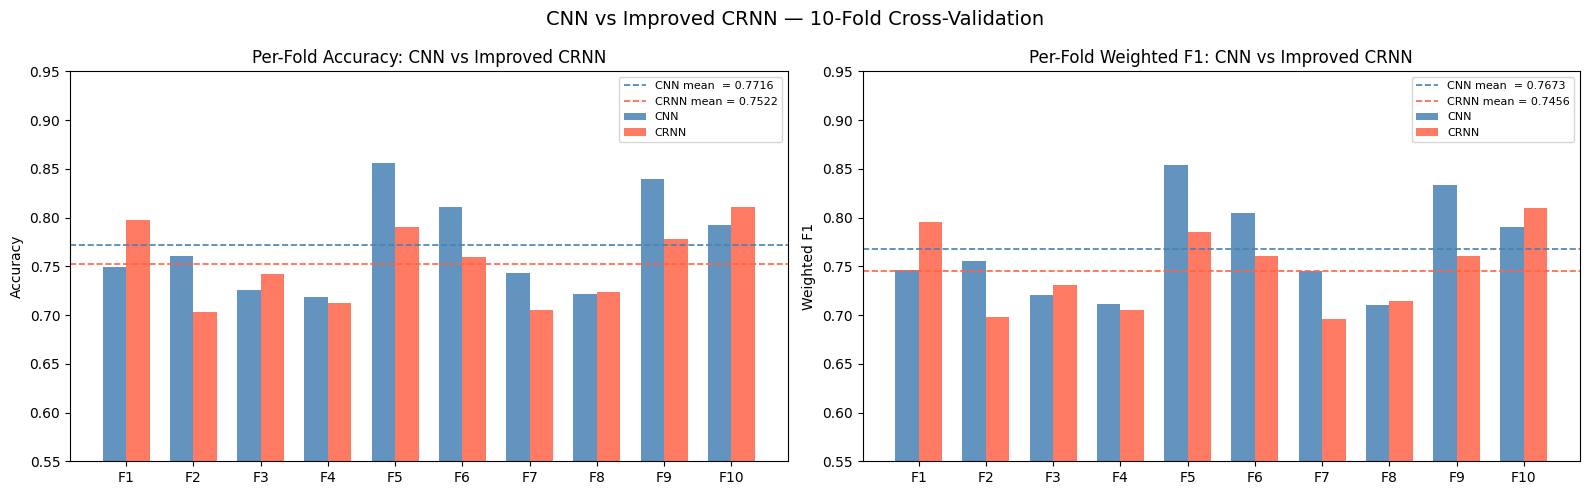

In [11]:
folds = list(range(1, 11))
x     = np.arange(len(folds))
w     = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, cnn_vals, crnn_vals, metric in zip(
        axes,
        [cnn_fold_accs, cnn_fold_f1s],
        [crnn_fold_accs, crnn_fold_f1s],
        ['Accuracy', 'Weighted F1']):
    ax.bar(x - w/2, cnn_vals,  w, label='CNN',  color='steelblue', alpha=0.85)
    ax.bar(x + w/2, crnn_vals, w, label='CRNN', color='tomato',    alpha=0.85)
    ax.axhline(np.mean(cnn_vals),  color='steelblue', linestyle='--', linewidth=1.2,
               label=f'CNN mean  = {np.mean(cnn_vals):.4f}')
    ax.axhline(np.mean(crnn_vals), color='tomato',    linestyle='--', linewidth=1.2,
               label=f'CRNN mean = {np.mean(crnn_vals):.4f}')
    ax.set_xticks(x)
    ax.set_xticklabels([f'F{f}' for f in folds])
    ax.set_ylabel(metric)
    ax.set_title(f'Per-Fold {metric}: CNN vs Improved CRNN')
    ax.set_ylim(0.55, 0.95)
    ax.legend(fontsize=8)

plt.suptitle('CNN vs Improved CRNN — 10-Fold Cross-Validation', fontsize=14)
plt.tight_layout()
plt.savefig('results_cnn_crnn/per_fold_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Confusion Matrices

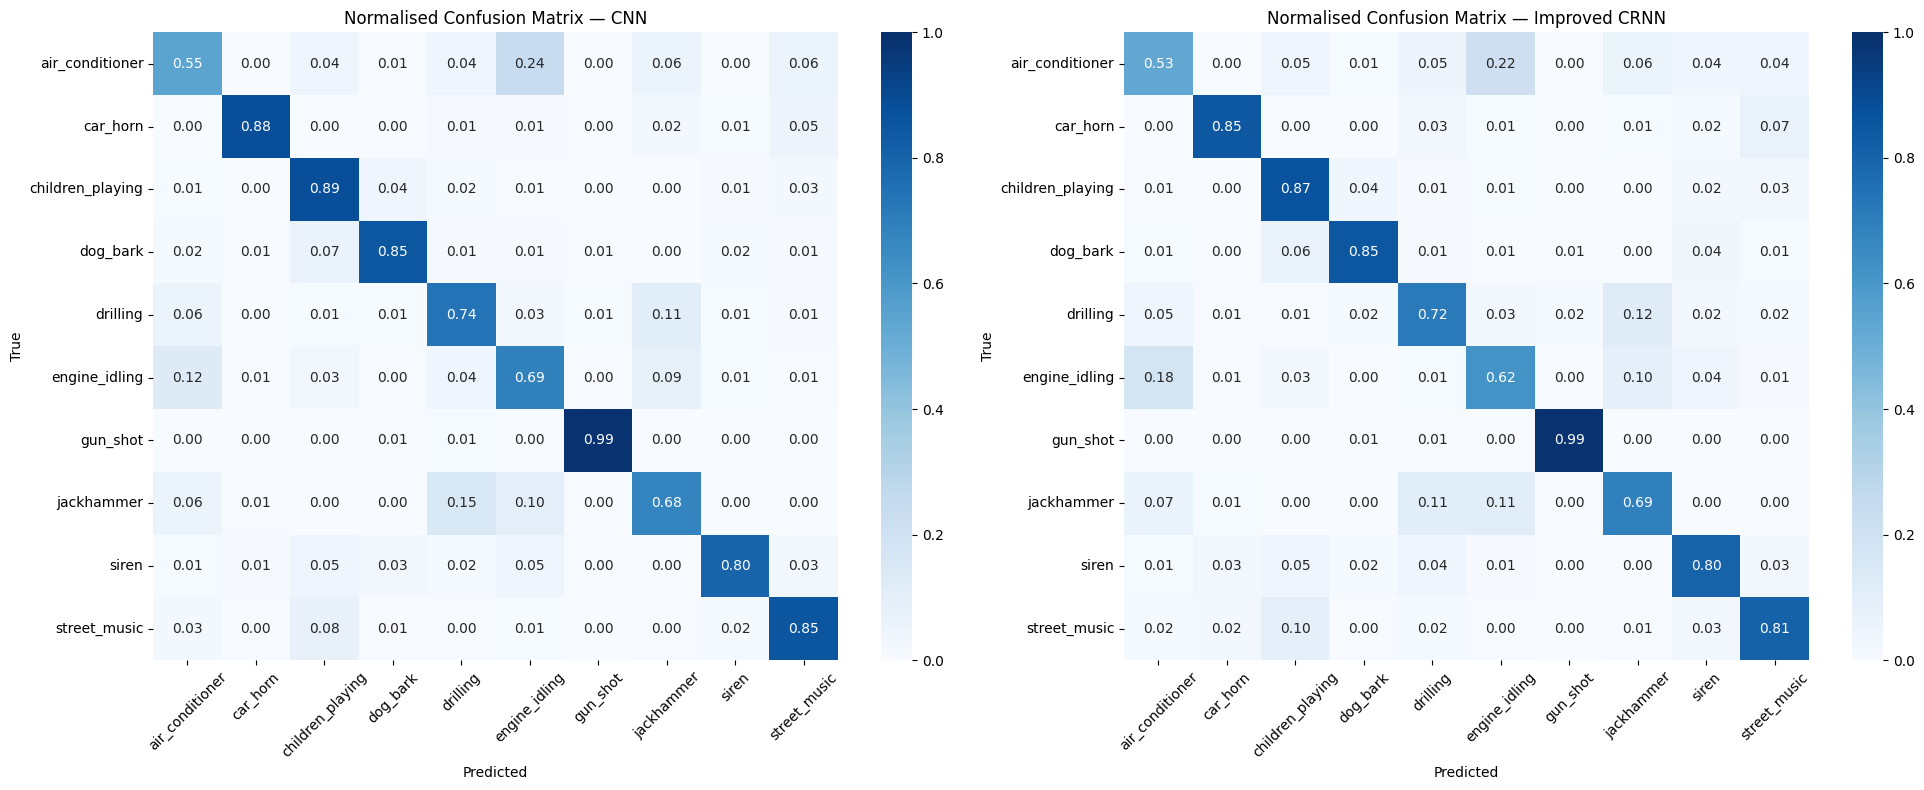

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, labels_g, preds_g, title in [
        (axes[0], cnn_all_labels,  cnn_all_preds,  'CNN'),
        (axes[1], crnn_all_labels, crnn_all_preds, 'Improved CRNN')]:
    cm      = confusion_matrix(labels_g, preds_g)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, vmin=0, vmax=1)
    ax.set_title(f'Normalised Confusion Matrix — {title}', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('results_cnn_crnn/confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

## 13. Per-Class F1 & Delta

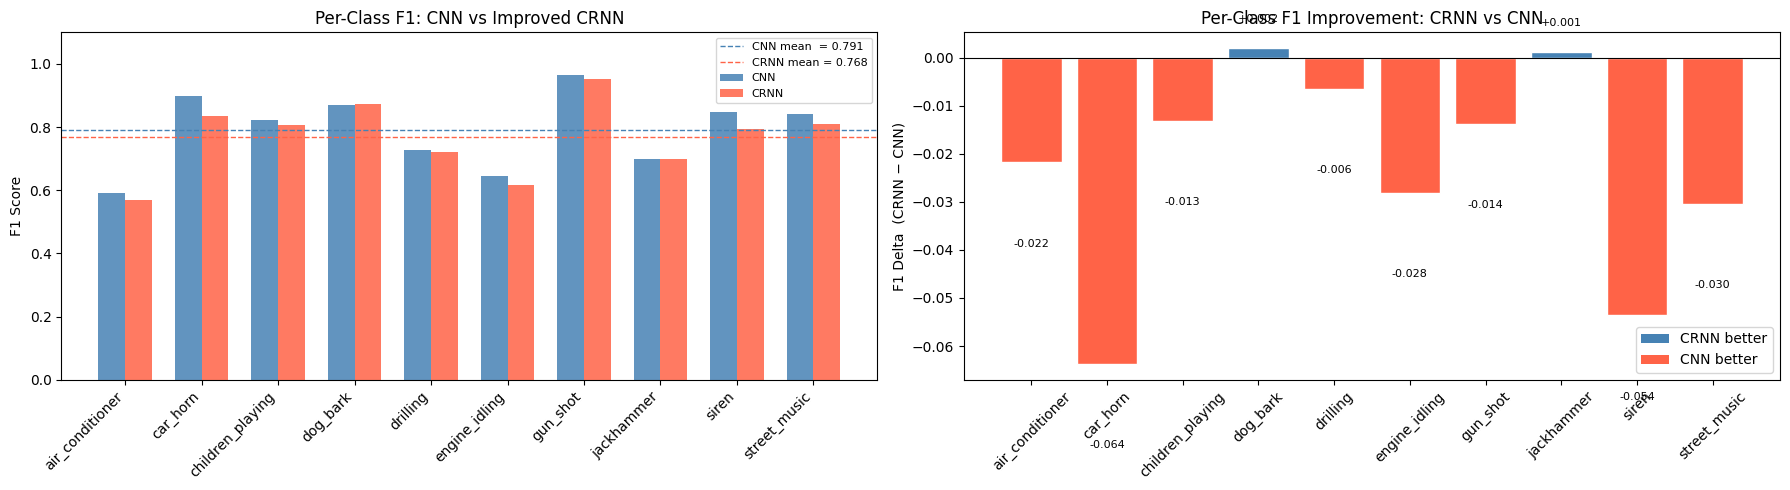


Per-class breakdown:
  Class                     CNN F1   CRNN F1     Delta
  ----------------------------------------------------
  dog_bark                  0.8715    0.8735   +0.0020
  jackhammer                0.6978    0.6989   +0.0011
  drilling                  0.7275    0.7210   -0.0065
  children_playing          0.8210    0.8078   -0.0132
  gun_shot                  0.9660    0.9523   -0.0137
  air_conditioner           0.5900    0.5682   -0.0217
  engine_idling             0.6442    0.6161   -0.0282
  street_music              0.8402    0.8099   -0.0304
  siren                     0.8483    0.7947   -0.0536
  car_horn                  0.8992    0.8354   -0.0637


In [13]:
cnn_pc_f1  = f1_score(cnn_all_labels,  cnn_all_preds,  average=None)
crnn_pc_f1 = f1_score(crnn_all_labels, crnn_all_preds, average=None)
delta      = crnn_pc_f1 - cnn_pc_f1

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Side-by-side per-class F1
x = np.arange(len(CLASS_NAMES))
w = 0.35
axes[0].bar(x - w/2, cnn_pc_f1,  w, label='CNN',  color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, crnn_pc_f1, w, label='CRNN', color='tomato',    alpha=0.85)
axes[0].axhline(np.mean(cnn_pc_f1),  color='steelblue', linestyle='--', linewidth=1,
                label=f'CNN mean  = {np.mean(cnn_pc_f1):.3f}')
axes[0].axhline(np.mean(crnn_pc_f1), color='tomato',    linestyle='--', linewidth=1,
                label=f'CRNN mean = {np.mean(crnn_pc_f1):.3f}')
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Per-Class F1: CNN vs Improved CRNN')
axes[0].legend(fontsize=8)

# Delta
colors = ['steelblue' if d >= 0 else 'tomato' for d in delta]
bars   = axes[1].bar(CLASS_NAMES, delta, color=colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('F1 Delta  (CRNN − CNN)')
axes[1].set_title('Per-Class F1 Improvement: CRNN vs CNN')
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, delta):
    ypos = val + 0.005 if val >= 0 else val - 0.018
    axes[1].text(bar.get_x() + bar.get_width() / 2, ypos,
                 f'{val:+.3f}', ha='center', va='bottom', fontsize=8)

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor='steelblue', label='CRNN better'),
    Patch(facecolor='tomato',    label='CNN better'),
], loc='lower right')

plt.tight_layout()
plt.savefig('results_cnn_crnn/per_class_f1.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nPer-class breakdown:')
print(f'  {"Class":<22}  {"CNN F1":>8}  {"CRNN F1":>8}  {"Delta":>8}')
print('  ' + '-' * 52)
for cls, c, r, d in sorted(
        zip(CLASS_NAMES, cnn_pc_f1, crnn_pc_f1, delta), key=lambda t: -t[3]):
    print(f'  {cls:<22}  {c:>8.4f}  {r:>8.4f}  {d:>+8.4f}')